In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/walmart_data.csv')
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [ ]:
''' Lets Understand some basic information about our dataset'''
df.shape



(550068, 10)

In [ ]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


In [ ]:
print(df['Gender'].value_counts())
print(df['Age'].value_counts())
print(df['City_Category'].value_counts())
print(df['Marital_Status'].value_counts())
print(df['Stay_In_Current_City_Years'].value_counts())

Gender
M    414259
F    135809
Name: count, dtype: int64
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64
Marital_Status
0    324731
1    225337
Name: count, dtype: int64
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64


In [ ]:
df.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422


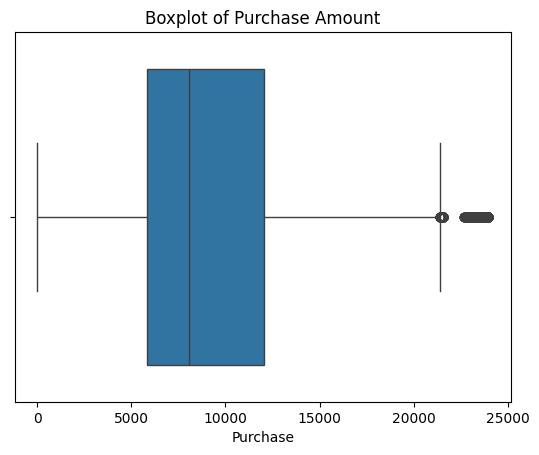

In [ ]:
sns.boxplot(data=df, x='Purchase')
plt.title('Boxplot of Purchase Amount')
plt.show()



*   As per the box plot we can see the outliers in the purchase data after 21k.
* Apart from purchase coloumn there are no other continous coloumn which have outliers


In [ ]:
''' To clip the data between 5 to 95 percentile'''

low_percentile = np.percentile(df['Purchase'], 5)
high_percentile = np.percentile(df['Purchase'], 95)

df['Clipped Purchase'] = np.clip(df['Purchase'], low_percentile, high_percentile)
df.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Clipped Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,15200


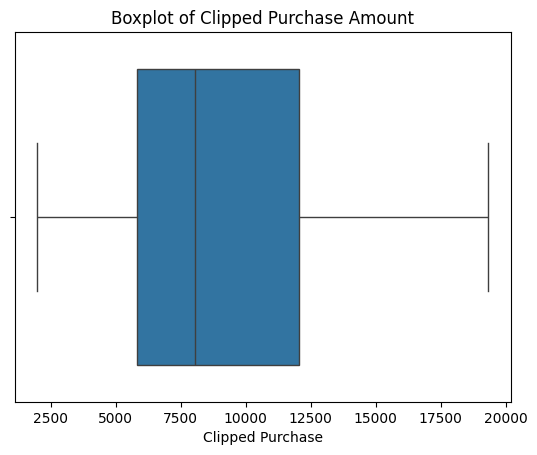

In [ ]:
sns.boxplot(data=df, x='Clipped Purchase')
plt.title('Boxplot of Clipped Purchase Amount')
plt.show()

#What products are different age groups buying?

<ipython-input-15-9e690a6467fd>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Age Groups", fontsize=10)


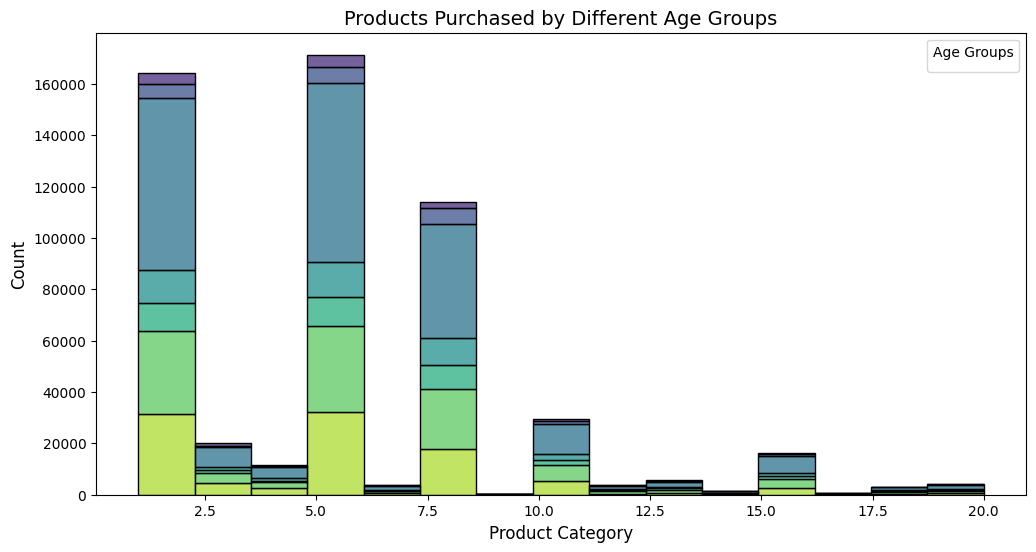

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="Product_Category", hue="Age", multiple="stack", kde=False, palette="viridis", bins=15)

# Adding Labels here
plt.title("Products Purchased by Different Age Groups", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Age Groups", fontsize=10)
plt.show()



*   Product which are bought most by the different age group seems to be 5th 1 and 8 that all the age group seems to buy.




In [ ]:
# Rechecking all the categories

df['Product_Category'].value_counts().sort_values(ascending= False)

,count
Product_Category,
5,150933
1,140378
8,113925
11,24287
2,23864
6,20466
3,20213
4,11753
16,9828


In [ ]:
df.groupby('Gender')['Purchase'].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


In [ ]:
gender_purchase =df.groupby('Gender')['Purchase'].agg(['sum','mean','count']).rename(columns={'sum':'Total Spend','mean':'Average Spend','count':'Total Transaction'})
gender_purchase

,Total Spend,Average Spend,Total Transaction
Gender,,,
F,1186232642,8734.565765,135809
M,3909580100,9437.526040,414259



- The total amount spent by the males are more compared to females
- This could be due to high population of males
- If we compare the average spent of male and females in comparison to the population in the data, females have more transactions than males
'''

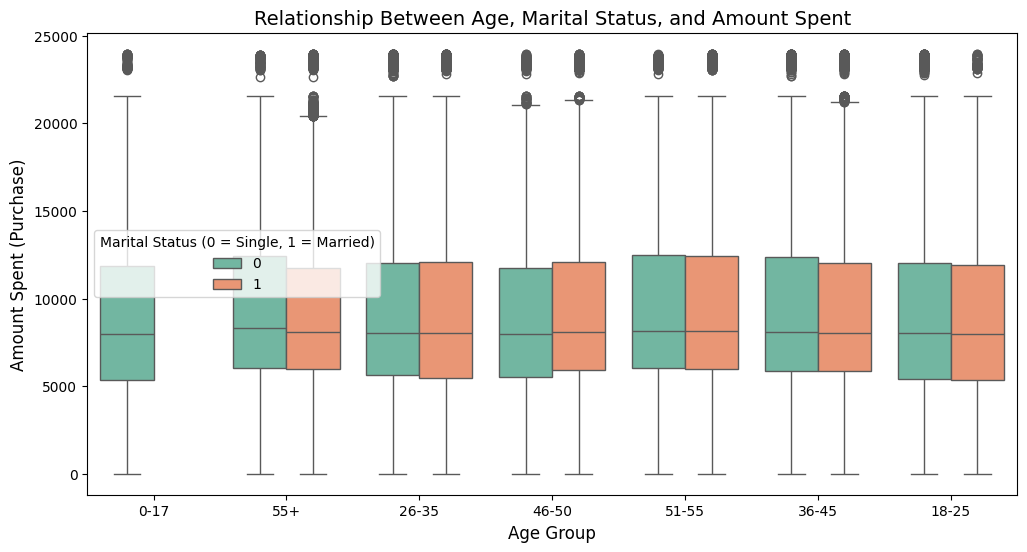

In [ ]:
# Relationship between Age, Marital Status, and Amount Spent
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Age", y="Purchase", hue="Marital_Status", palette="Set2")


plt.title("Relationship Between Age, Marital Status, and Amount Spent", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Amount Spent (Purchase)", fontsize=12)
plt.legend(title="Marital Status (0 = Single, 1 = Married)", fontsize=10)
plt.show()

<ipython-input-19-83ee1812ac9d>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Gender (M = Male, F = Female)", fontsize=10)


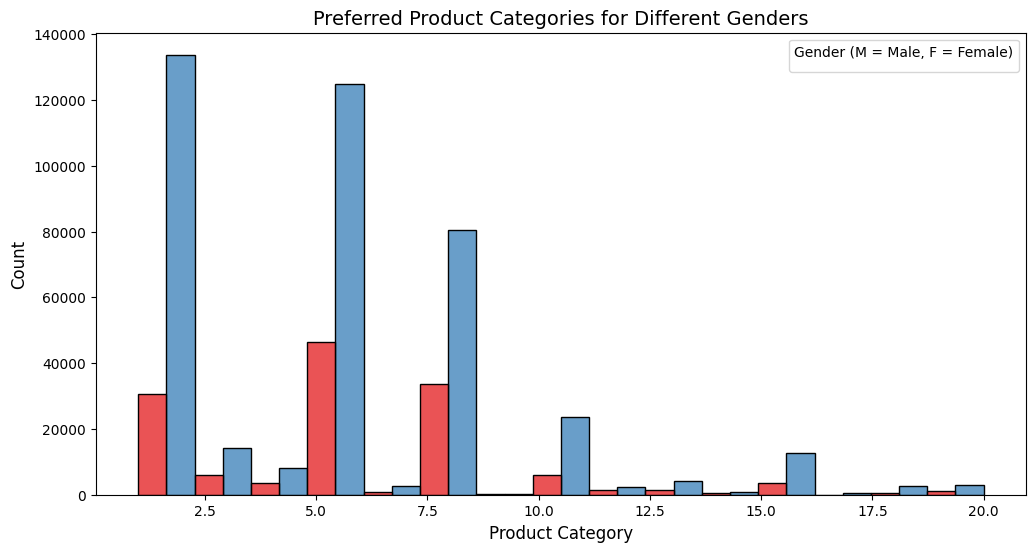

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="Product_Category", hue="Gender", multiple="dodge", palette="Set1", bins=15, kde=False)

#
plt.title("Preferred Product Categories for Different Genders", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Gender (M = Male, F = Female)", fontsize=10)
plt.show()

* Red Color ( Male ) Blue Color (Female)

- The average product purchased by female is much much heigher than male in all product category

Confidence Intervals for Full Dataset:
Male: (9422.006365643234, 9452.464290093878)
Female: (8710.510668107414, 8761.337665581808)

Confidence Intervals for Sample Size 300:
Male: (8930.315833333334, 9986.211916666667)
Female: (8155.8054999999995, 9328.537250000001)

Confidence Intervals for Sample Size 3000:
Male: (9238.861033333333, 9624.821916666666)
Female: (8570.581133333335, 8921.04645)

Confidence Intervals for Sample Size 30000:
Male: (9379.589955, 9494.029431666666)
Female: (8682.775670833333, 8785.048895833334)


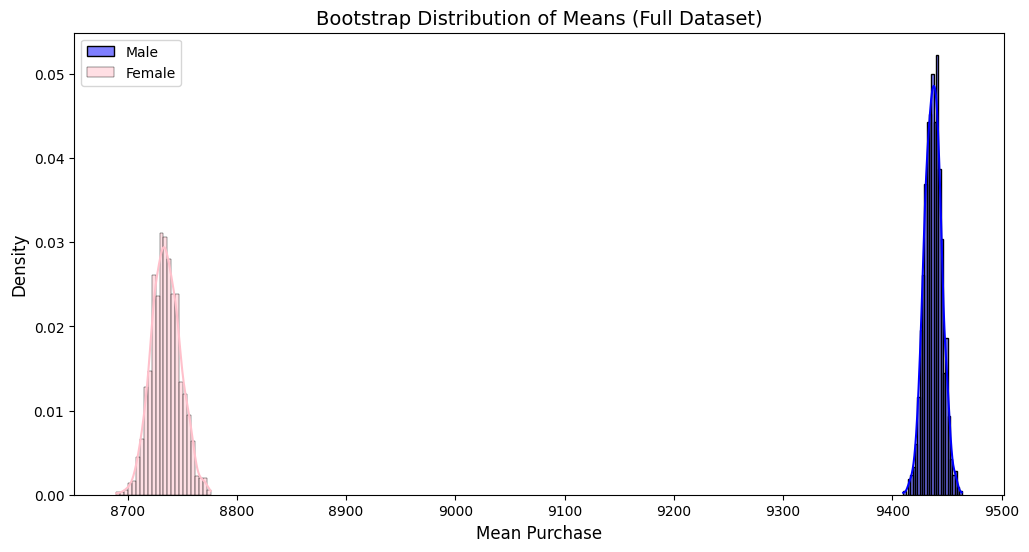

In [ ]:
#Average Mean purchase by male and female
def bootstrap_confidence_interval(data, n_samples, n_iterations=1000, confidence=0.95):

    means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=n_samples, replace=True)
        means.append(np.mean(sample))


    lower_bound = np.percentile(means, (1-confidence)/2 * 100)
    upper_bound = np.percentile(means, (1 + confidence)/2 * 100)
    return lower_bound, upper_bound, means

# Spliting  data by gender
male_data = df[df['Gender'] == 'M']['Purchase']
female_data = df[df['Gender'] == 'F']['Purchase']

# Full dataset confidence intervals
male_full_ci = bootstrap_confidence_interval(male_data, len(male_data))
female_full_ci = bootstrap_confidence_interval(female_data, len(female_data))

# Smaller sample sizes
sample_sizes = [300, 3000, 30000]
results = {}

for size in sample_sizes:
    male_ci = bootstrap_confidence_interval(male_data, size)
    female_ci = bootstrap_confidence_interval(female_data, size)
    results[size] = {
        'Male': male_ci,
        'Female': female_ci
    }

# Display results
print("Confidence Intervals for Full Dataset:")
print(f"Male: {male_full_ci[:2]}")
print(f"Female: {female_full_ci[:2]}")

for size, ci in results.items():
    print(f"\nConfidence Intervals for Sample Size {size}:")
    print(f"Male: {ci['Male'][:2]}")
    print(f"Female: {ci['Female'][:2]}")

# Optional: Visualize the bootstrap distributions
plt.figure(figsize=(12, 6))
sns.histplot(male_full_ci[2], color="blue", label="Male", kde=True, stat="density")
sns.histplot(female_full_ci[2], color="pink", label="Female", kde=True, stat="density")
plt.title("Bootstrap Distribution of Means (Full Dataset)", fontsize=14)
plt.xlabel("Mean Purchase", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()

- As per the boot distribution mean of male is average is hiegher as compared to female,
there can be different reasons for that.
- One would be that population of male is hiegher than female
- But mean purchase of female matches to male even after they have lower population

Confidence Intervals for Full Dataset:
Married: (9238.62766700542, 9281.828106902107)
Single: (9249.591818920891, 9282.584482309974)

Confidence Intervals for Sample Size 300:
Married: (8650.063, 9816.673583333333)
Single: (8708.818166666666, 9853.1235)

Confidence Intervals for Sample Size 3000:
Married: (9086.436608333333, 9446.964866666665)
Single: (9086.103725, 9450.477891666667)

Confidence Intervals for Sample Size 30000:
Married: (9209.502839166667, 9317.292230833333)
Single: (9208.030484166668, 9325.149401666667)


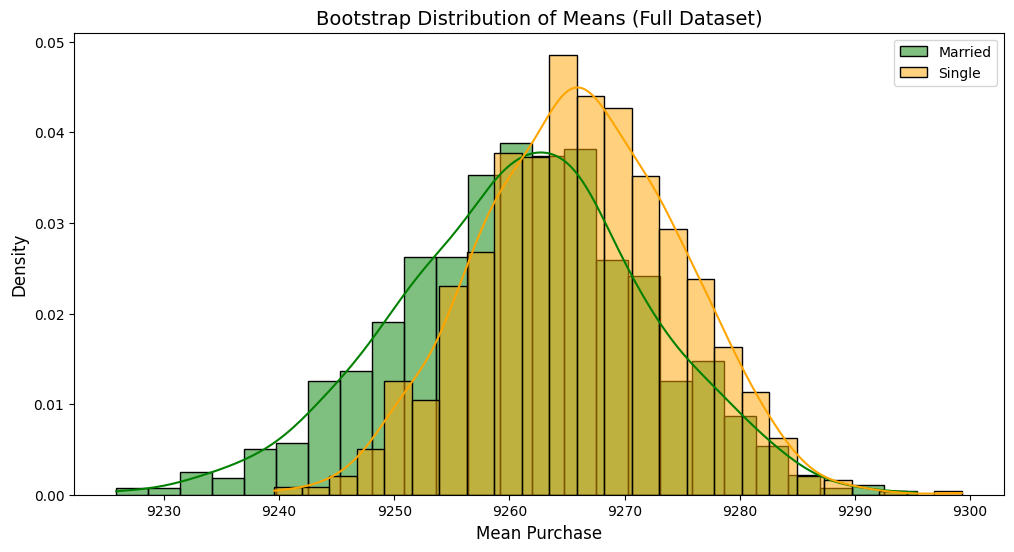

In [ ]:
# Average spent by married and single
def bootstrap_confidence_interval(data, n_samples, n_iterations=1000, confidence=0.95):

    means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=n_samples, replace=True)
        means.append(np.mean(sample))

    # Calculating  confidence intervals
    lower_bound = np.percentile(means, (1-confidence)/2 * 100)
    upper_bound = np.percentile(means, (1 + confidence)/2 * 100)
    return lower_bound, upper_bound, means

# Split data based on Marital_Status
married_data = df[df['Marital_Status'] == 1]['Purchase']
single_data = df[df['Marital_Status'] == 0]['Purchase']

# Confidence intervals for full dataset
married_full_ci = bootstrap_confidence_interval(married_data, len(married_data))
single_full_ci = bootstrap_confidence_interval(single_data, len(single_data))

# Confidence intervals for smaller sample sizes
sample_sizes = [300, 3000, 30000]
results = {}

for size in sample_sizes:
    married_ci = bootstrap_confidence_interval(married_data, size)
    single_ci = bootstrap_confidence_interval(single_data, size)
    results[size] = {
        'Married': married_ci,
        'Single': single_ci
    }

# Results
print("Confidence Intervals for Full Dataset:")
print(f"Married: {married_full_ci[:2]}")
print(f"Single: {single_full_ci[:2]}")

for size, ci in results.items():
    print(f"\nConfidence Intervals for Sample Size {size}:")
    print(f"Married: {ci['Married'][:2]}")
    print(f"Single: {ci['Single'][:2]}")

# Visualization of the graph
plt.figure(figsize=(12, 6))
sns.histplot(married_full_ci[2], color="green", label="Married", kde=True, stat="density")
sns.histplot(single_full_ci[2], color="orange", label="Single", kde=True, stat="density")
plt.title("Bootstrap Distribution of Means (Full Dataset)", fontsize=14)
plt.xlabel("Mean Purchase", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()

- While Single have average mean purchase heigher than married, but there is not much difference on two of them.
- Both Single have married have smiliar mean purchase

Confidence Intervals for Full Dataset (by Age Group):
0-17: (8850.101375645609, 9022.53998145941)
55+: (9272.237573242188, 9411.050708007813)
26-35: (9231.055188717912, 9272.461317609876)
46-50: (9161.981041443294, 9252.439347607273)
51-55: (9485.770432586167, 9586.333490688552)
36-45: (9300.836651804786, 9361.19066542136)
18-25: (9139.508969997993, 9199.99677327915)

Confidence Intervals for Sample Size 300 (by Age Group):
0-17: (8312.576916666667, 9465.22625)
55+: (8837.931416666668, 9897.847166666666)
26-35: (8695.809083333332, 9830.056666666667)
46-50: (8666.753, 9747.786166666667)
51-55: (8974.973833333333, 10143.181)
36-45: (8789.158833333333, 9911.149500000001)
18-25: (8607.730666666666, 9711.377333333332)

Confidence Intervals for Sample Size 3000 (by Age Group):
0-17: (8751.568691666667, 9113.405499999999)
55+: (9157.612583333334, 9515.266616666668)
26-35: (9075.244541666667, 9419.460200000001)
46-50: (9027.4945, 9389.734725)
51-55: (9349.3351, 9721.938741666667)
36-45: (9153.

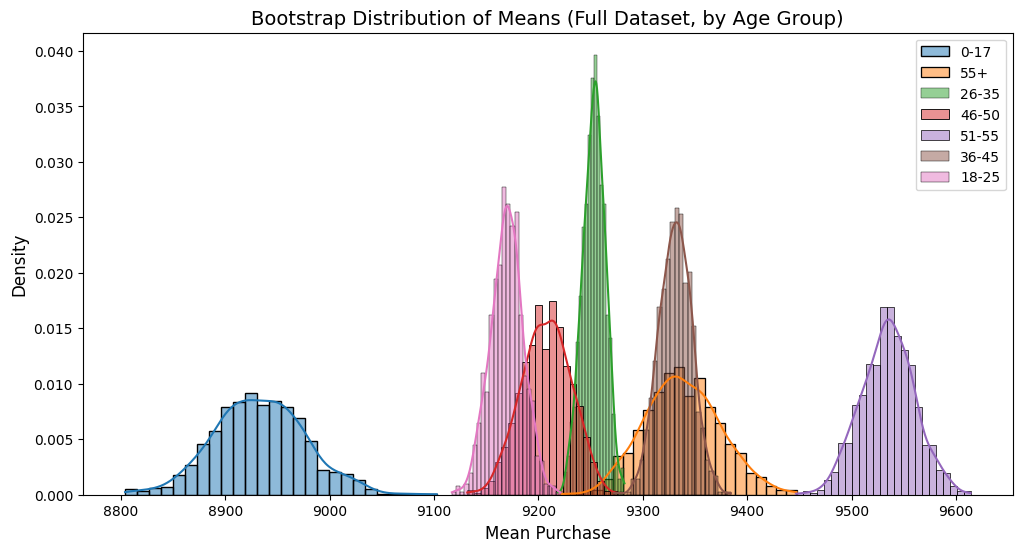

In [ ]:
#Using the same function for Age intervals

def bootstrap_confidence_interval(data, n_samples, n_iterations=1000, confidence=0.95):

    means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=n_samples, replace=True)
        means.append(np.mean(sample))


    lower_bound = np.percentile(means, (1 - confidence) / 2 * 100)
    upper_bound = np.percentile(means, (1 + confidence) / 2 * 100)
    return lower_bound, upper_bound, means

age_groups = df['Age'].unique()
results = {}

for age_group in age_groups:
    age_data = df[df['Age'] == age_group]['Purchase']


    full_ci = bootstrap_confidence_interval(age_data, len(age_data))
    results[age_group] = {'Full': full_ci}


    sample_sizes = [300, 3000, 30000]
    for size in sample_sizes:
        if size <= len(age_data):  # Ensure sample size is not larger than group size
            ci = bootstrap_confidence_interval(age_data, size)
            results[age_group][size] = ci

# Printing results
print("Confidence Intervals for Full Dataset (by Age Group):")
for age_group, ci_data in results.items():
    print(f"{age_group}: {ci_data['Full'][:2]}")

for size in sample_sizes:
    print(f"\nConfidence Intervals for Sample Size {size} (by Age Group):")
    for age_group, ci_data in results.items():
        if size in ci_data:
            print(f"{age_group}: {ci_data[size][:2]}")

# Visualizaton graph
plt.figure(figsize=(12, 6))
for age_group, ci_data in results.items():
    sns.histplot(ci_data['Full'][2], label=age_group, kde=True, stat="density")
plt.title("Bootstrap Distribution of Means (Full Dataset, by Age Group)", fontsize=14)
plt.xlabel("Mean Purchase", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()



*   The age group 26-35 purchased the heighest purchase as this is the prime age
*   2nd Heighest group for the purchase is 18-25  
*  Lowest purchase is for the age group 0-17 as they are the childerns or are not adult for shopping



# Insights  Recommendation

- Walmart should focus on the age groups between 18-24 to 25-34 as they purchase most

- Product categories 1, 5, 8 and have most purchase rates, so to bring up the sale of other categories they can give a offer with these product, so people can try those products as well

- They should give offers to married couples and old age people so that there purchase can be increased